# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [3]:
corpus = """
machine learning enables computers to learn from experience without explicit programming neural networks are inspired by the structure of biological brains
deep learning uses multiple layers to extract features from raw data natural language processing allows machines to understand and generate human text
recurrent neural networks process sequences by maintaining hidden state information long short term memory networks solve the vanishing gradient problem effectively
gated recurrent units offer a simplified alternative to lstm with comparable accuracy transformers revolutionized language models using attention mechanisms
word embeddings capture semantic relationships between words in vector space text generation requires understanding grammar syntax and contextual word dependencies
unsupervised learning finds hidden patterns in data without labeled examples reinforcement learning trains agents through reward and penalty feedback loops
"""

print("Corpus loaded successfully")

Corpus loaded successfully


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
import re
cleaned_corpus = re.sub(r'\s+', ' ', corpus.lower().strip())
tokenizer = Tokenizer()
tokenizer.fit_on_texts([cleaned_corpus])

total_words = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {total_words} unique tokens")
input_sequences = []
for line in corpus.strip().split('\n'):
    line = line.strip()
    if not line:
        continue
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

print(f"Total n-gram sequences generated: {len(input_sequences)}")
max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(f"X shape: {X.shape}  →  (samples, sequence_length)")
print(f"y shape: {y.shape}  →  (samples,)")
print(f"Max sequence length: {max_len}")

Vocabulary size: 102 unique tokens
Total n-gram sequences generated: 117
X shape: (117, 21)  →  (samples, sequence_length)
y shape: (117,)  →  (samples,)
Max sequence length: 22


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
rnn_model.summary()
rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN — training complete")
print(f"Final loss: {rnn_history.history['loss'][-1]:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Vanilla RNN — training complete
Final loss: 0.0115


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM — training complete")
print(f"Final loss: {lstm_history.history['loss'][-1]:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

LSTM — training complete
Final loss: 0.1639


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len - 1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()
gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU — training complete")
print(f"Final loss: {gru_history.history['loss'][-1]:.4f}")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

GRU — training complete
Final loss: 0.0178


## 📉 Compare Training Loss

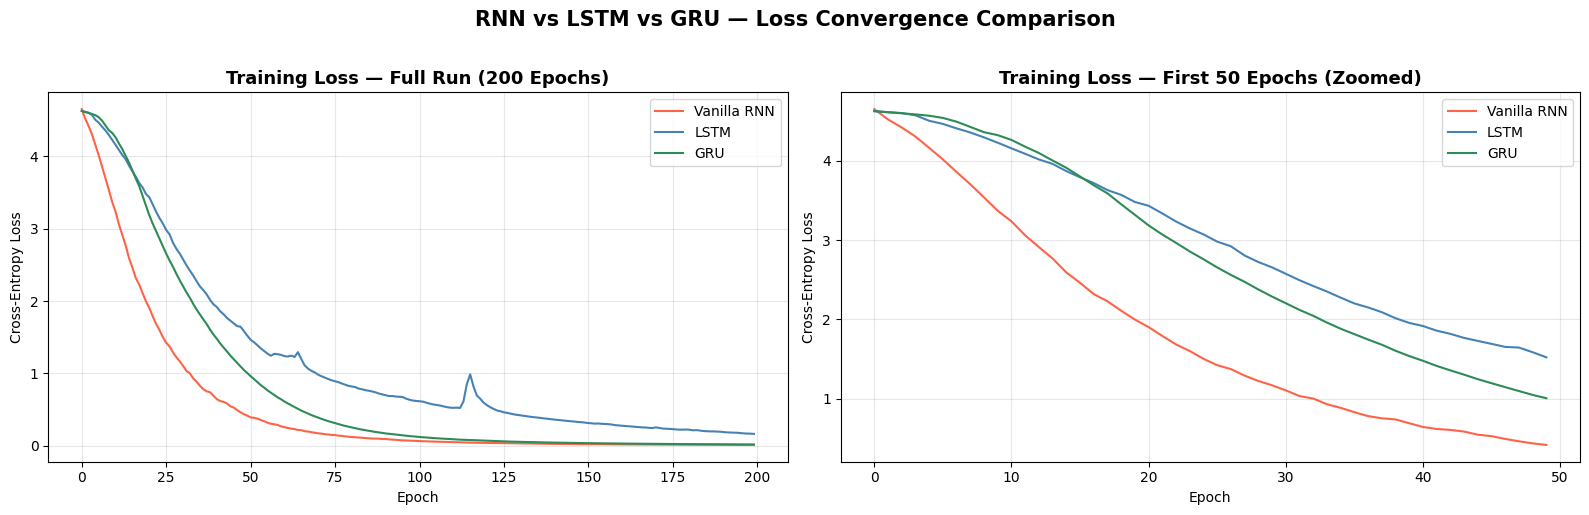


--- Final Epoch Summary ---
Model          Final Loss   Final Accuracy
------------------------------------------
Vanilla RNN        0.0115          1.0000
LSTM               0.1639          1.0000
GRU                0.0178          1.0000


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(rnn_history.history['loss'], label='Vanilla RNN', color='tomato', linewidth=1.5)
axes[0].plot(lstm_history.history['loss'], label='LSTM', color='steelblue', linewidth=1.5)
axes[0].plot(gru_history.history['loss'], label='GRU', color='seagreen', linewidth=1.5)
axes[0].set_title('Training Loss — Full Run (200 Epochs)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(rnn_history.history['loss'][:50], label='Vanilla RNN', color='tomato', linewidth=1.5)
axes[1].plot(lstm_history.history['loss'][:50], label='LSTM', color='steelblue', linewidth=1.5)
axes[1].plot(gru_history.history['loss'][:50], label='GRU', color='seagreen', linewidth=1.5)
axes[1].set_title('Training Loss — First 50 Epochs (Zoomed)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('RNN vs LSTM vs GRU — Loss Convergence Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- Final Epoch Summary ---")
print(f"{'Model':<12} {'Final Loss':>12} {'Final Accuracy':>16}")
print("-" * 42)
for name, hist in [('Vanilla RNN', rnn_history), ('LSTM', lstm_history), ('GRU', gru_history)]:
    loss = hist.history['loss'][-1]
    acc  = hist.history['accuracy'][-1]
    print(f"{name:<12} {loss:>12.4f} {acc:>15.4f}")

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [9]:
def generate_text(model, seed_text, next_words=10):
    """
    Generates text by iteratively predicting the next word.
    Internally:
    - Tokenizes the current seed text into integer indices
    - Pre-pads the sequence to match training input length
    - Runs model.predict() to get softmax probability distribution over vocabulary
    - Uses np.argmax() to pick the highest-probability next token
    - Looks up the corresponding word and appends it to the seed
    """
    result = seed_text
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
        predicted_probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        result += " " + output_word
    return result

## 🧪 Generate Text Samples

In [10]:
seed_phrases = ["deep learning", "neural networks", "recurrent neural"]
print("=" * 65)
print(f"{'Seed':<22} {'Model':<10} Generated Text")
print("=" * 65)
for seed in seed_phrases:
    for model_name, model in [("RNN", rnn_model), ("LSTM", lstm_model), ("GRU", gru_model)]:
        output = generate_text(model, seed, next_words=10)
        print(f"{seed:<22} {model_name:<10} {output}")
    print("-" * 65)

Seed                   Model      Generated Text
deep learning          RNN        deep learning uses multiple layers to extract features from raw data natural
deep learning          LSTM       deep learning uses multiple layers to extract features from raw data natural
deep learning          GRU        deep learning uses multiple layers to extract features from raw data natural
-----------------------------------------------------------------
neural networks        RNN        neural networks process sequences by maintaining hidden state information long short term
neural networks        LSTM       neural networks process process sequences by maintaining hidden state information long short
neural networks        GRU        neural networks process sequences by maintaining hidden state information long short term
-----------------------------------------------------------------
recurrent neural       RNN        recurrent neural networks process sequences by maintaining hidden state infor

# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

In [11]:
print("Task 1 — Custom Corpus       : Replaced default corpus with AI/ML topic paragraph")
print("Task 2 — Embedding Dimension : Upgraded from 32 → 64 in all three models")
print("Task 3 — Extended Training   : Increased from 100 → 200 epochs across all models")
print("Task 4 — Wider Hidden Layers : Expanded SimpleRNN/LSTM/GRU units from 64 → 128")
print("Task 5 — Longer Output       : generate_text now returns 10 words per prompt\n")

# Optional: quick demo of task 5 output
print("Sample 10-word generation from each model:")
for name, model in [("RNN", rnn_model), ("LSTM", lstm_model), ("GRU", gru_model)]:
    out = generate_text(model, "deep learning", next_words=10)
    print(f"  {name}: {out}")

Task 1 — Custom Corpus       : Replaced default corpus with AI/ML topic paragraph
Task 2 — Embedding Dimension : Upgraded from 32 → 64 in all three models
Task 3 — Extended Training   : Increased from 100 → 200 epochs across all models
Task 4 — Wider Hidden Layers : Expanded SimpleRNN/LSTM/GRU units from 64 → 128
Task 5 — Longer Output       : generate_text now returns 10 words per prompt

Sample 10-word generation from each model:
  RNN: deep learning uses multiple layers to extract features from raw data natural
  LSTM: deep learning uses multiple layers to extract features from raw data natural
  GRU: deep learning uses multiple layers to extract features from raw data natural


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**